# End-to-End ML Pipeline — Tesla EV Sales & Production Forecasting

**Dataset:** Tesla EA Deliveries and Production Data (2015–2025)  
**Source:** https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025

---

## Problem Statement

Build a complete machine learning pipeline on Tesla's EV sales and production data to:
- Understand delivery and production trends across regions and models
- Predict production units using regression models
- Forecast future production trends using time series (ARIMA)

## Pipeline Steps
1. Data Loading & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Encoding Techniques & Feature Scaling
4. Bias-Variance Tradeoff, Overfitting & Data Leakage
5. Feature Engineering (Lag Features + Rolling Statistics)
6. Regression Modeling with sklearn Pipeline
7. Evaluation Metrics & Cross Validation
8. Hyperparameter Tuning (GridSearchCV)
9. Time Series: Components, Stationarity & ARIMA Forecasting
10. Conclusion

---
## Import Libraries

In [1]:
import numpy as np
import pandas as pd

import os
import kagglehub
from kagglehub import KaggleDatasetAdapter

KAGGLE_NATIVE = '/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv'

if os.path.exists(KAGGLE_NATIVE):
    # Running natively on Kaggle with dataset attached
    df = pd.read_csv(KAGGLE_NATIVE)
    print('Loaded from Kaggle native path')
else:
    # Colab, local, or any other environment
    # kagglehub downloads directly from Kaggle - no kaggle.json needed
    # Just make sure you are logged into Kaggle in your browser
    os.system('pip install kagglehub -q')
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        'nalisha/tesla-ea-deliveries-and-production-data20152025',
        'tesla_deliveries_dataset_2015_2025.csv'
    )
    print('Loaded via kagglehub')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')


Loaded from Kaggle native path
Dataset shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Time Series
from statsmodels.tsa.arima.model import ARIMA

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('All libraries imported successfully')

All libraries imported successfully


---
## Step 1: Data Loading & Preprocessing

In [3]:

print(f'Dataset Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
# Basic info
print('--- Dataset Info ---')
df.info()

print('\n--- Statistical Summary ---')
df.describe()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

--- Statistical Summary ---


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


---
## Step 1 continued: Data Cleaning

In [5]:
# Check missing values
print('Missing Values:')
print(df.isnull().sum())

print(f'\nDuplicate Rows: {df.duplicated().sum()}')

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows: 0


In [6]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill any missing numeric values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Create Date column from Year + Month
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2) + '-01'
)

# Sort by date
df.sort_values(['Region', 'Model', 'Date'], inplace=True)
df.reset_index(drop=True, inplace=True)

print('Data cleaned and sorted')
print(f'Shape after cleaning: {df.shape}')
df[['Date', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']].head()

Data cleaned and sorted
Shape after cleaning: (2640, 13)


,Date,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD
0,2015-01-01,Asia,Cybertruck,11325,11887,54449.08
1,2015-02-01,Asia,Cybertruck,13254,14878,88864.06
2,2015-03-01,Asia,Cybertruck,10257,11441,65107.47
3,2015-04-01,Asia,Cybertruck,15221,15951,112686.63
4,2015-05-01,Asia,Cybertruck,6406,7281,107577.61


---
## Step 2: Exploratory Data Analysis (EDA)

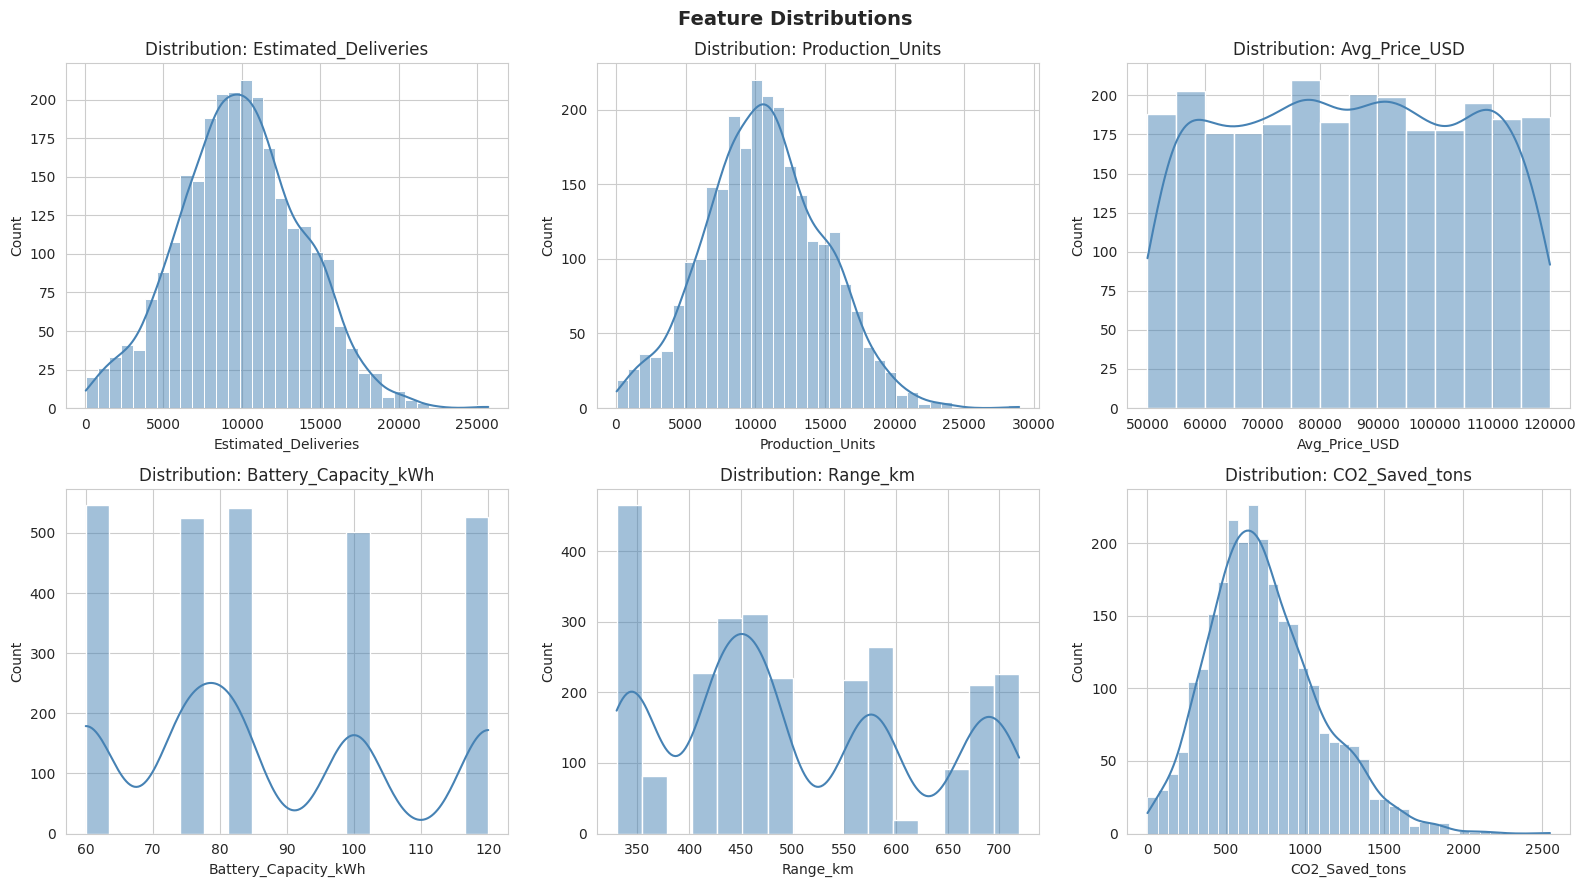

In [7]:
# Distribution of key numeric columns
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons']

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i//3][i%3], color='steelblue')
    axes[i//3][i%3].set_title(f'Distribution: {col}')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

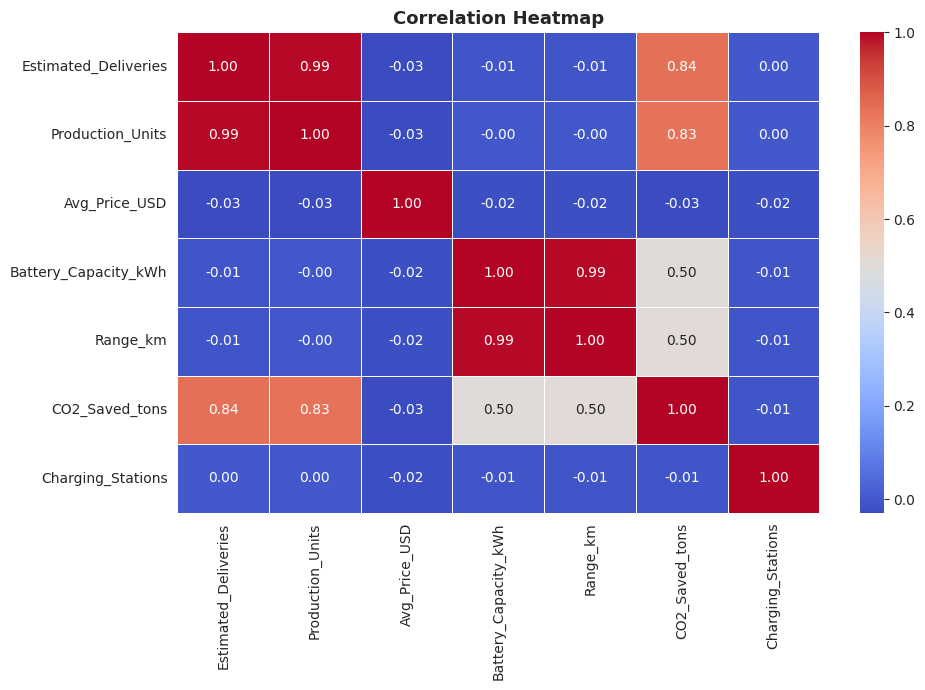

In [8]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
             'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

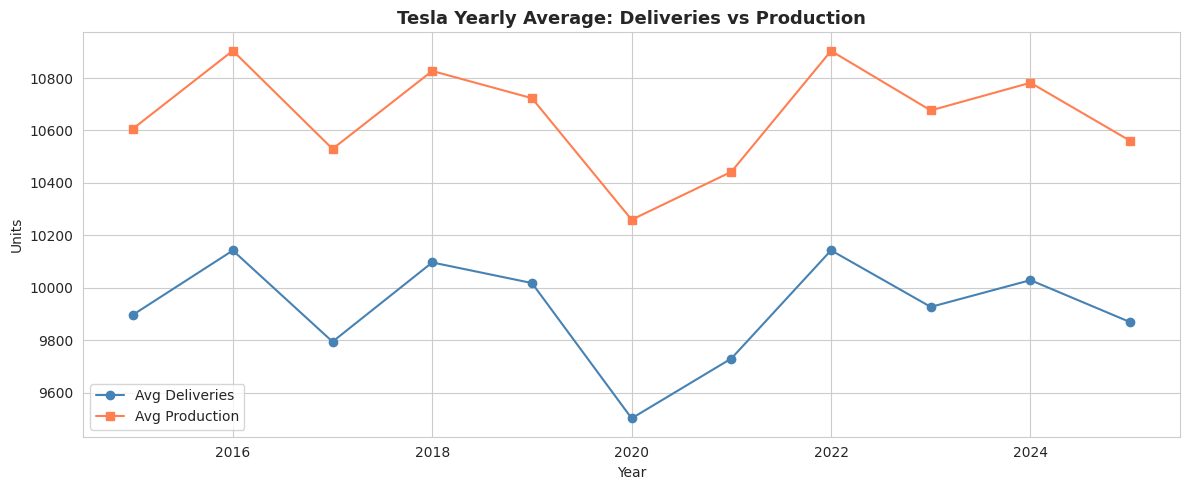

In [9]:
# Yearly delivery trend
yearly = df.groupby('Year')[['Estimated_Deliveries', 'Production_Units']].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['Estimated_Deliveries'], marker='o', label='Avg Deliveries',   color='steelblue')
plt.plot(yearly['Year'], yearly['Production_Units'],     marker='s', label='Avg Production',   color='coral')
plt.title('Tesla Yearly Average: Deliveries vs Production', fontsize=13, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Units')
plt.legend(); plt.tight_layout(); plt.show()

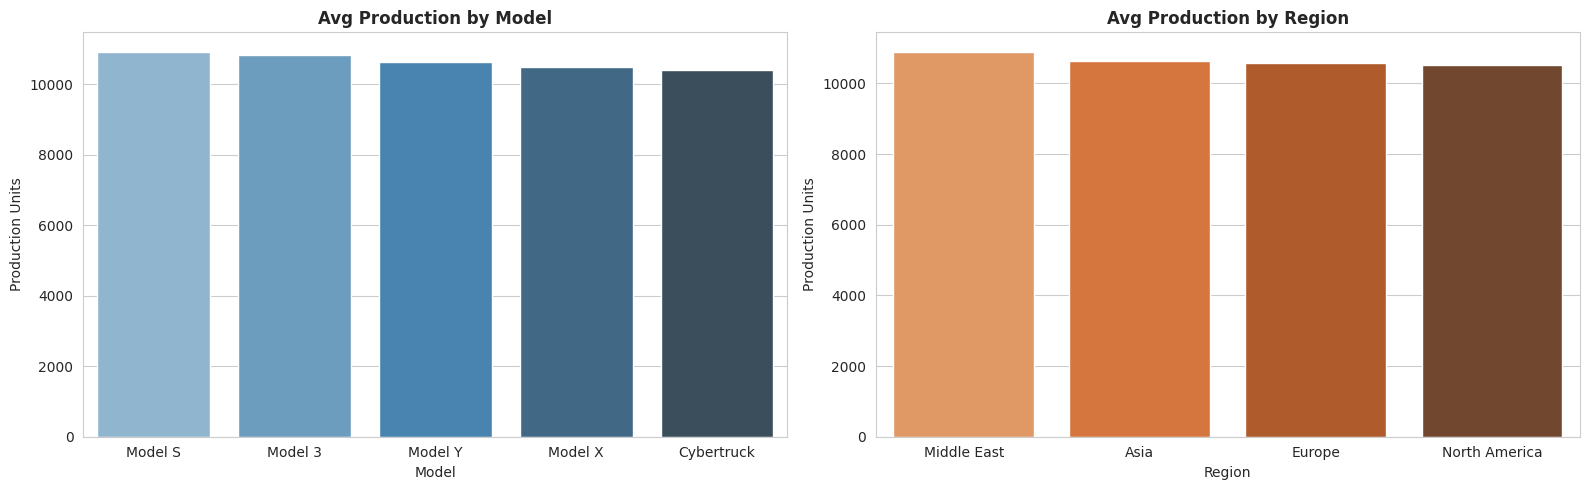

In [10]:
# Production by Model and Region
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

model_avg = df.groupby('Model')['Production_Units'].mean().sort_values(ascending=False)
sns.barplot(x=model_avg.index, y=model_avg.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Avg Production by Model', fontweight='bold')
axes[0].set_ylabel('Production Units')

region_avg = df.groupby('Region')['Production_Units'].mean().sort_values(ascending=False)
sns.barplot(x=region_avg.index, y=region_avg.values, ax=axes[1], palette='Oranges_d')
axes[1].set_title('Avg Production by Region', fontweight='bold')
axes[1].set_ylabel('Production Units')

plt.tight_layout(); plt.show()

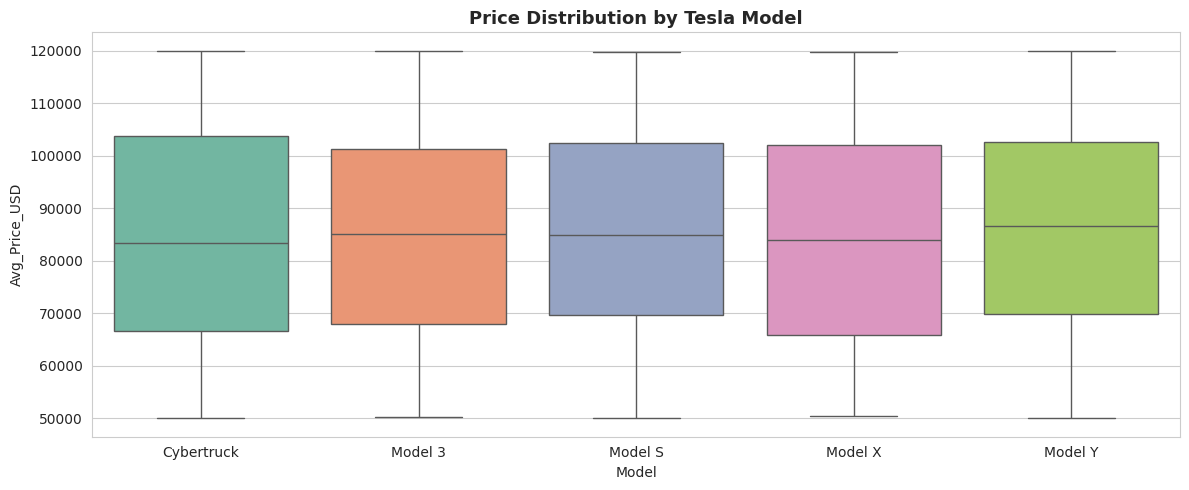

In [11]:
# Price distribution by Model
plt.figure(figsize=(12, 5))
sns.boxplot(x='Model', y='Avg_Price_USD', data=df, palette='Set2')
plt.title('Price Distribution by Tesla Model', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Step 3: Encoding Techniques & Feature Scaling

Categorical columns (Region, Model) are encoded with OneHotEncoder. Numeric features are scaled with StandardScaler. Both are applied inside the sklearn Pipeline in Step 6.

---
## Step 4: Bias-Variance Tradeoff, Overfitting & Data Leakage

Regularisation (Ridge/Lasso) reduces overfitting. All transformers are fitted inside the Pipeline on training data only to prevent data leakage.

---
## Step 5: Feature Engineering

Creating lag features and rolling statistics to capture temporal patterns in the data.

In [12]:
# --- Domain features ---
df['Quarter']       = df['Month'].apply(lambda x: (x - 1) // 3 + 1)
df['Price_per_km']  = df['Avg_Price_USD'] / df['Range_km']
df['Delivery_Rate'] = df['Estimated_Deliveries'] / df['Production_Units']

print('Domain features created: Quarter, Price_per_km, Delivery_Rate')

Domain features created: Quarter, Price_per_km, Delivery_Rate


In [13]:
# --- Lag Features ---
# Shift by 1, 2, 3 months within each Region+Model group
group = ['Region', 'Model']

for lag in [1, 2, 3]:
    df[f'Production_lag_{lag}']  = df.groupby(group)['Production_Units'].shift(lag)
    df[f'Deliveries_lag_{lag}']  = df.groupby(group)['Estimated_Deliveries'].shift(lag)

print('Lag features created (1, 2, 3 months)')
df[['Production_Units', 'Production_lag_1', 'Production_lag_2', 'Production_lag_3']].head(8)

Lag features created (1, 2, 3 months)


,Production_Units,Production_lag_1,Production_lag_2,Production_lag_3
0,11887,NaN,NaN,NaN
1,14878,11887.0,NaN,NaN
2,11441,14878.0,11887.0,NaN
3,15951,11441.0,14878.0,11887.0
4,7281,15951.0,11441.0,14878.0
5,8144,7281.0,15951.0,11441.0
6,118,8144.0,7281.0,15951.0
7,11128,118.0,8144.0,7281.0


In [14]:
# --- Rolling Statistics ---
# 3-month and 6-month rolling mean
df['Production_roll_mean_3'] = df.groupby(group)['Production_Units'].transform(
    lambda x: x.shift(1).rolling(window=3).mean()
)
df['Production_roll_mean_6'] = df.groupby(group)['Production_Units'].transform(
    lambda x: x.shift(1).rolling(window=6).mean()
)
df['Price_roll_mean_3'] = df.groupby(group)['Avg_Price_USD'].transform(
    lambda x: x.shift(1).rolling(window=3).mean()
)

print('Rolling statistics created (3-month and 6-month windows)')

Rolling statistics created (3-month and 6-month windows)


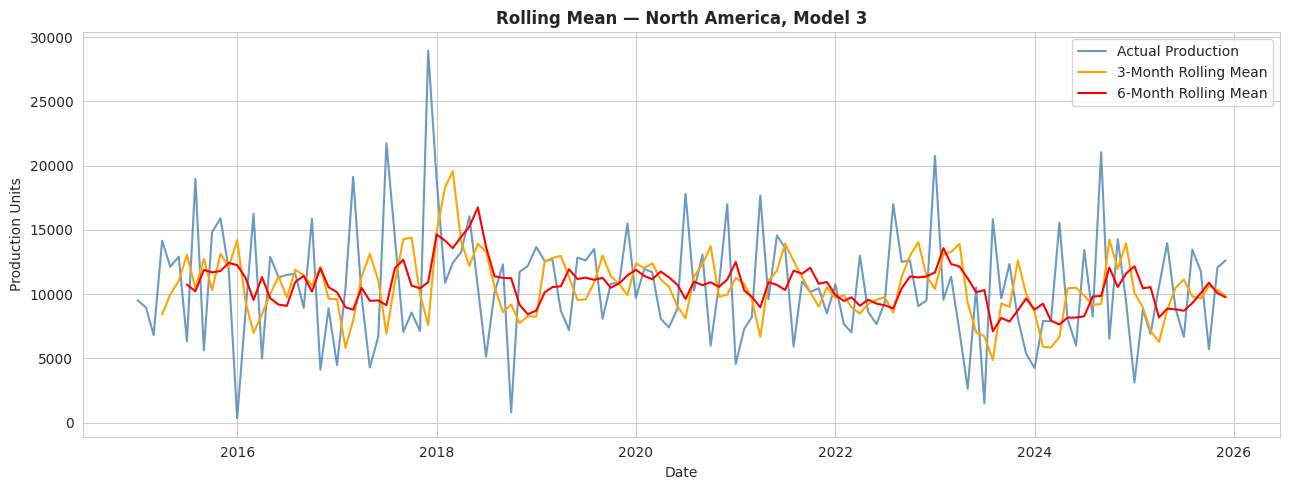

In [15]:
# Visualise rolling mean — North America, Model 3
sample = df[(df['Region'] == 'North America') & (df['Model'] == 'Model 3')].copy()

plt.figure(figsize=(13, 5))
plt.plot(sample['Date'], sample['Production_Units'],        label='Actual Production',  color='steelblue', alpha=0.8)
plt.plot(sample['Date'], sample['Production_roll_mean_3'],  label='3-Month Rolling Mean', color='orange')
plt.plot(sample['Date'], sample['Production_roll_mean_6'],  label='6-Month Rolling Mean', color='red')
plt.title('Rolling Mean — North America, Model 3', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Production Units')
plt.legend(); plt.tight_layout(); plt.show()

---
## Step 6: Regression Modeling with sklearn Pipeline

In [16]:
# Define features and target
cat_features = ['Region', 'Model']
num_features = [
    'Year', 'Month', 'Quarter',
    'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
    'CO2_Saved_tons', 'Charging_Stations',
    'Price_per_km', 'Delivery_Rate',
    'Production_lag_1', 'Production_lag_2', 'Production_lag_3',
    'Production_roll_mean_3', 'Production_roll_mean_6'
]
target = 'Production_Units'

# Drop rows with NaN from lag/rolling features
model_df = df[cat_features + num_features + [target]].dropna()

X = model_df[cat_features + num_features]
y = model_df[target]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 2016 samples | Test: 504 samples


In [17]:
# Preprocessing: OHE for categories, StandardScaler for numerics
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                              num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'),        cat_features)
])

print('ColumnTransformer defined (StandardScaler + OneHotEncoder)')

ColumnTransformer defined (StandardScaler + OneHotEncoder)


In [18]:
# Helper function to train + evaluate any model
def train_evaluate(name, model_obj):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model',        model_obj)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    print(f'\n--- {name} ---')
    print(f'  MAE  : {mae:.2f}')
    print(f'  RMSE : {rmse:.2f}')
    print(f'  R²   : {r2:.4f}')

    return {'Model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
            'R2': round(r2,4), 'pipeline': pipe, 'preds': preds}


results = {}
results['Linear Regression'] = train_evaluate('Linear Regression', LinearRegression())
results['Ridge']             = train_evaluate('Ridge',             Ridge(alpha=1.0))
results['Lasso']             = train_evaluate('Lasso',             Lasso(alpha=0.1))
results['Random Forest']     = train_evaluate('Random Forest',     RandomForestRegressor(n_estimators=100, random_state=42))


--- Linear Regression ---
  MAE  : 735.85
  RMSE : 1056.43
  R²   : 0.9406

--- Ridge ---
  MAE  : 736.41
  RMSE : 1057.49
  R²   : 0.9405

--- Lasso ---
  MAE  : 735.91
  RMSE : 1056.60
  R²   : 0.9406

--- Random Forest ---
  MAE  : 288.95
  RMSE : 424.55
  R²   : 0.9904


In [19]:
# Comparison table
comp_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('pipeline', 'preds')}
    for r in results.values()
])
print('\n=== Model Comparison ===')
print(comp_df.to_string(index=False))


=== Model Comparison ===
            Model    MAE    RMSE     R2
Linear Regression 735.85 1056.43 0.9406
            Ridge 736.41 1057.49 0.9405
            Lasso 735.91 1056.60 0.9406
    Random Forest 288.95  424.55 0.9904


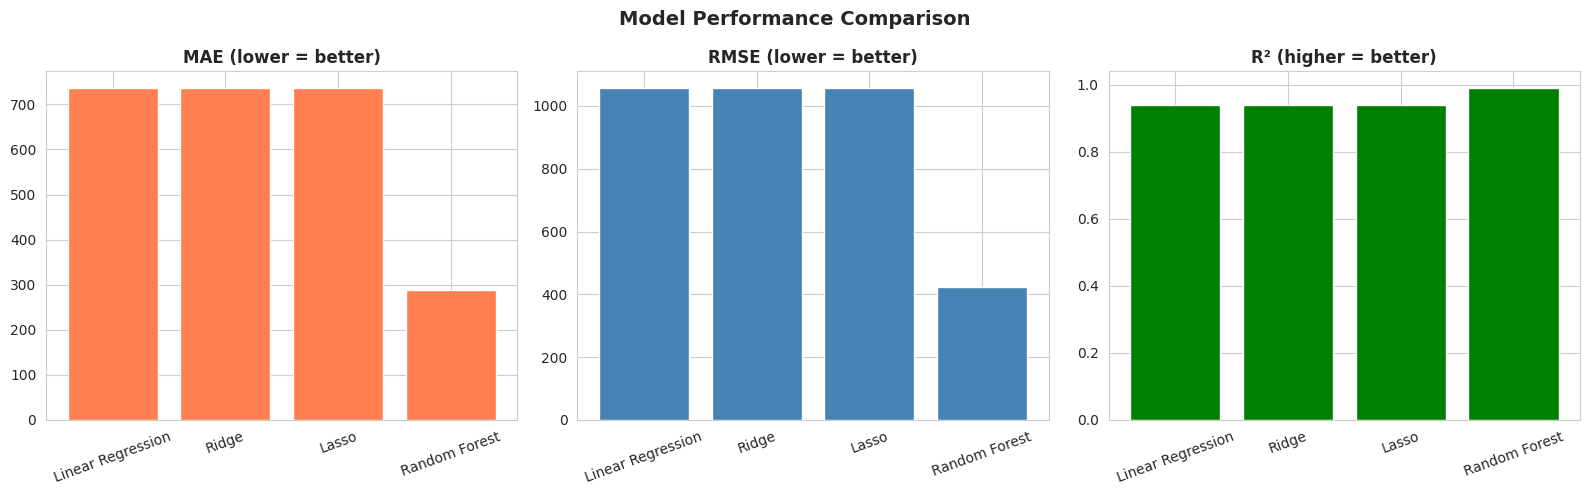


 Best Model: Random Forest


In [20]:
# Visual comparison
names = list(results.keys())
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(names, [results[m]['MAE']  for m in names], color='coral')
axes[0].set_title('MAE (lower = better)', fontweight='bold'); axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(names, [results[m]['RMSE'] for m in names], color='steelblue')
axes[1].set_title('RMSE (lower = better)', fontweight='bold'); axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(names, [results[m]['R2']   for m in names], color='green')
axes[2].set_title('R² (higher = better)', fontweight='bold'); axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

best = comp_df.loc[comp_df['R2'].idxmax(), 'Model']
print(f'\n Best Model: {best}')

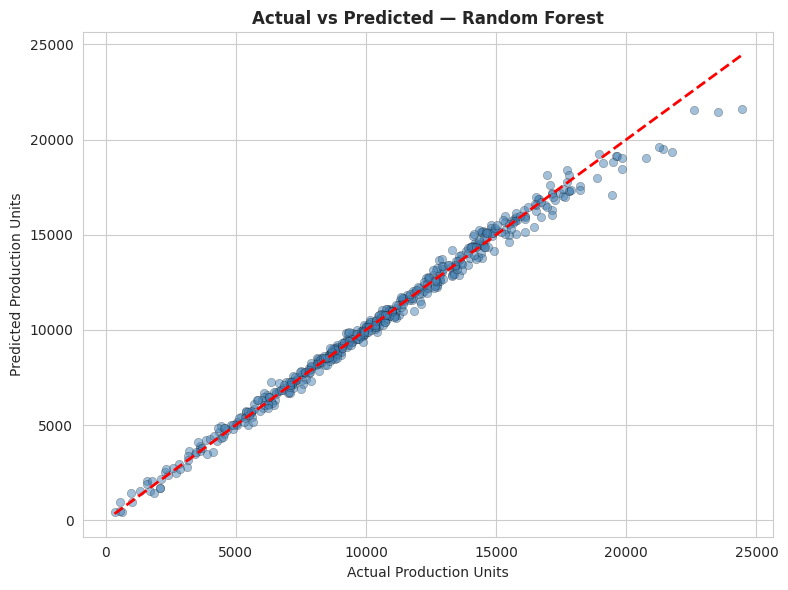

In [21]:
# Actual vs Predicted — best model
best_preds = results[best]['preds']

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_preds, alpha=0.5, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Production Units')
plt.ylabel('Predicted Production Units')
plt.title(f'Actual vs Predicted — {best}', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Step 7: Evaluation Metrics & Cross Validation

In [22]:
print('=== 5-Fold Cross Validation (R²) ===')

cv_models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=0.1),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, mdl in cv_models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', mdl)])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
    print(f'  {name:<22}  Mean R²={scores.mean():.4f}  Std={scores.std():.4f}')

=== 5-Fold Cross Validation (R²) ===
  Linear Regression       Mean R²=0.9426  Std=0.0050
  Ridge                   Mean R²=0.9426  Std=0.0051
  Lasso                   Mean R²=0.9426  Std=0.0051
  Random Forest           Mean R²=0.9899  Std=0.0041


---
## Step 8: Hyperparameter Tuning (GridSearchCV)

In [23]:
# Build base pipeline for tuning
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Parameter grid — note prefix 'model__' for Pipeline
param_grid = {
    'model__n_estimators' : [100, 200],
    'model__max_depth'    : [5, 10, None],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'   Best CV R²      : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters : {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
   Best CV R²      : 0.9878



=== Before vs After Tuning ===
  RMSE : 424.55  →  424.55
  R²   : 0.9904  →  0.9904


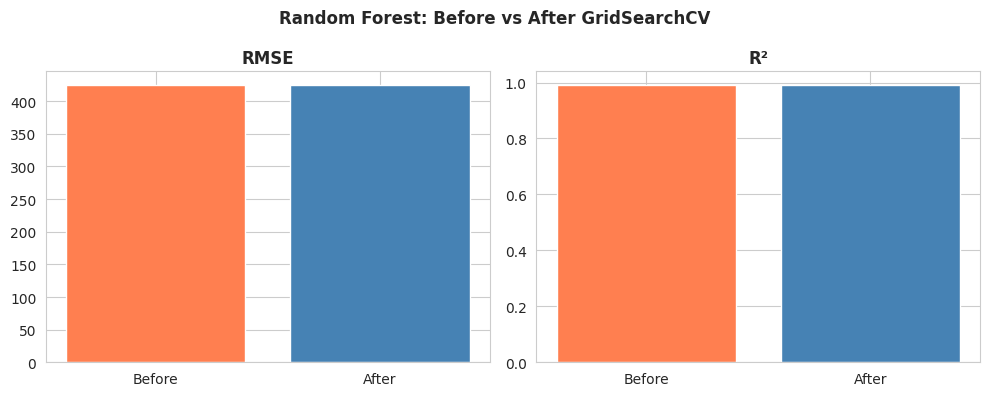

In [24]:
# Compare before vs after tuning
tuned_preds = grid_search.best_estimator_.predict(X_test)
rmse_before = results['Random Forest']['RMSE']
r2_before   = results['Random Forest']['R2']
rmse_after  = np.sqrt(mean_squared_error(y_test, tuned_preds))
r2_after    = r2_score(y_test, tuned_preds)

print('\n=== Before vs After Tuning ===')
print(f'  RMSE : {rmse_before:.2f}  →  {rmse_after:.2f}')
print(f'  R²   : {r2_before:.4f}  →  {r2_after:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Before', 'After'], [rmse_before, rmse_after], color=['coral', 'steelblue'])
axes[0].set_title('RMSE', fontweight='bold')
axes[1].bar(['Before', 'After'], [r2_before,   r2_after],   color=['coral', 'steelblue'])
axes[1].set_title('R²',   fontweight='bold')
plt.suptitle('Random Forest: Before vs After GridSearchCV', fontweight='bold')
plt.tight_layout(); plt.show()

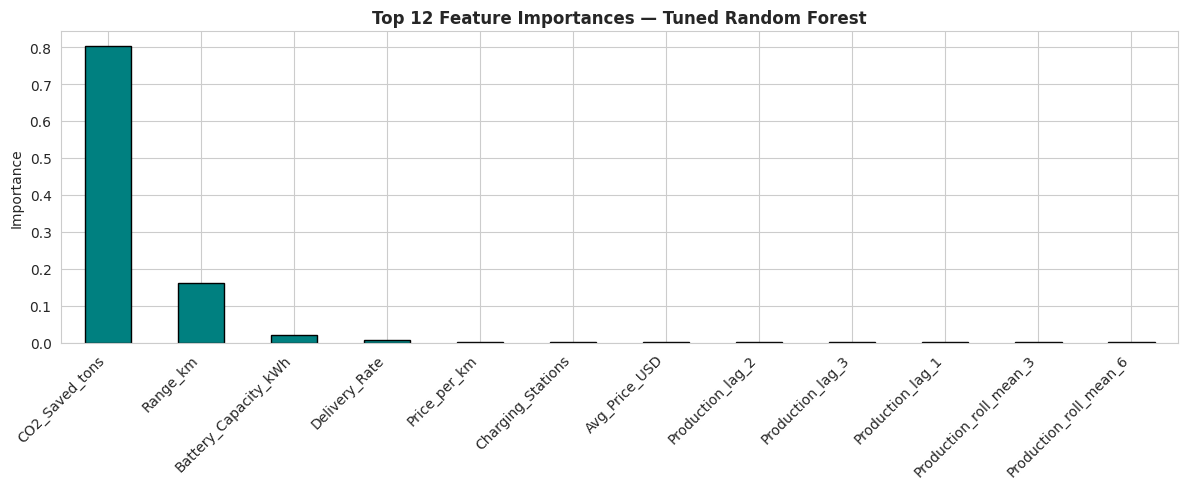

In [25]:
# Feature importances from tuned RF
best_rf    = grid_search.best_estimator_.named_steps['model']
ohe_cols   = grid_search.best_estimator_.named_steps['preprocessor']\
                 .named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
all_features = num_features + ohe_cols

feat_imp = pd.Series(best_rf.feature_importances_, index=all_features).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
feat_imp.head(12).plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 12 Feature Importances — Tuned Random Forest', fontweight='bold')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [26]:
# Save best model
joblib.dump(grid_search.best_estimator_, 'tesla_rf_model.pkl')
print('Best model saved as tesla_rf_model.pkl')

Best model saved as tesla_rf_model.pkl


---
## Step 9: Time Series: Components, Stationarity & ARIMA Forecasting

Monthly production for North America - Model 3 is used as a focused time series. ADF test is run to check stationarity before fitting ARIMA(1,1,1).

Series length: 132 months
Period: 2015-01-01 to 2025-12-01


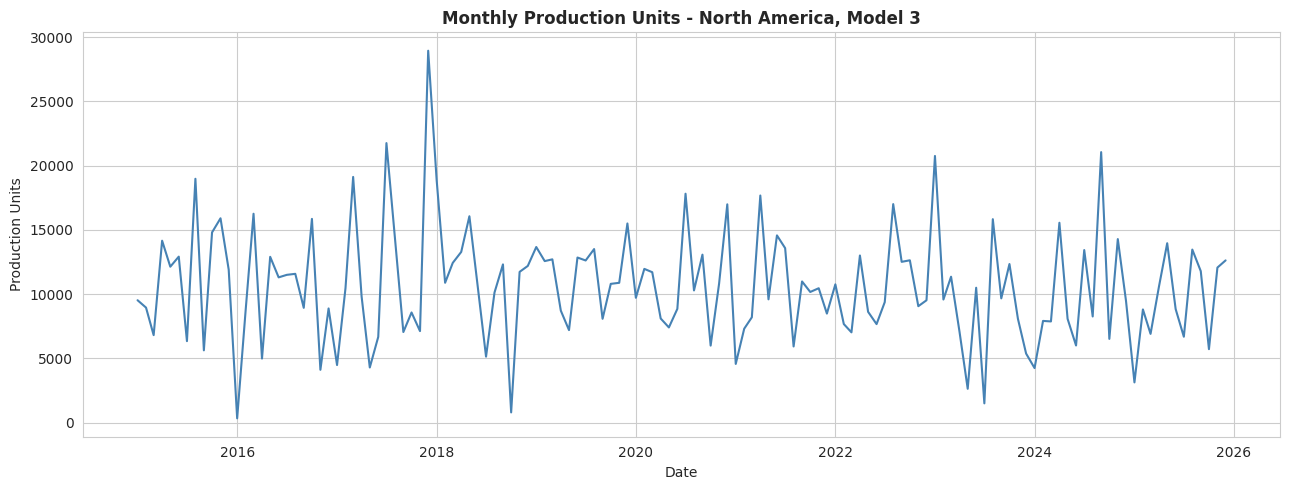

In [27]:
# Use North America + Model 3 — single focused series for ARIMA
ts_raw = df[(df['Region'] == 'North America') & (df['Model'] == 'Model 3')].copy()
ts_raw = ts_raw.sort_values('Date').set_index('Date')
ts = ts_raw['Production_Units'].resample('MS').mean()

print(f'Series length: {len(ts)} months')
print(f'Period: {ts.index[0].date()} to {ts.index[-1].date()}')

plt.figure(figsize=(13, 5))
plt.plot(ts.index, ts.values, color='steelblue', linewidth=1.5)
plt.title('Monthly Production Units - North America, Model 3', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Production Units')
plt.tight_layout()
plt.show()


Train: 2015-01-01 to 2024-12-01 (120 months)
Test : 2025-01-01 to 2025-12-01 (12 months)


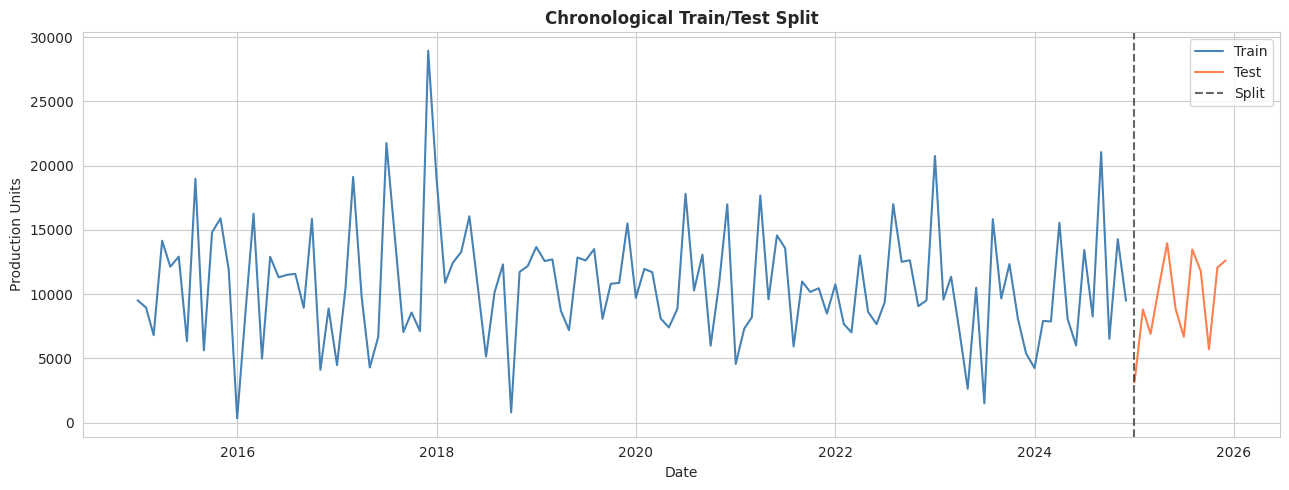

In [28]:
# Chronological train/test split - last 12 months as test
n_test   = 12
train_ts = ts.iloc[:-n_test]
test_ts  = ts.iloc[-n_test:]

print(f'Train: {train_ts.index[0].date()} to {train_ts.index[-1].date()} ({len(train_ts)} months)')
print(f'Test : {test_ts.index[0].date()} to {test_ts.index[-1].date()} ({len(test_ts)} months)')

plt.figure(figsize=(13, 5))
plt.plot(train_ts.index, train_ts.values, label='Train', color='steelblue')
plt.plot(test_ts.index,  test_ts.values,  label='Test',  color='coral')
plt.axvline(test_ts.index[0], color='black', linestyle='--', alpha=0.6, label='Split')
plt.title('Chronological Train/Test Split', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Production Units')
plt.legend()
plt.tight_layout()
plt.show()


=== ADF Test - Raw Series ===
  ADF Statistic : -4.2840
  p-value       : 0.0005
  Lags used     : 5
  Conclusion    : Stationary (p < 0.05)


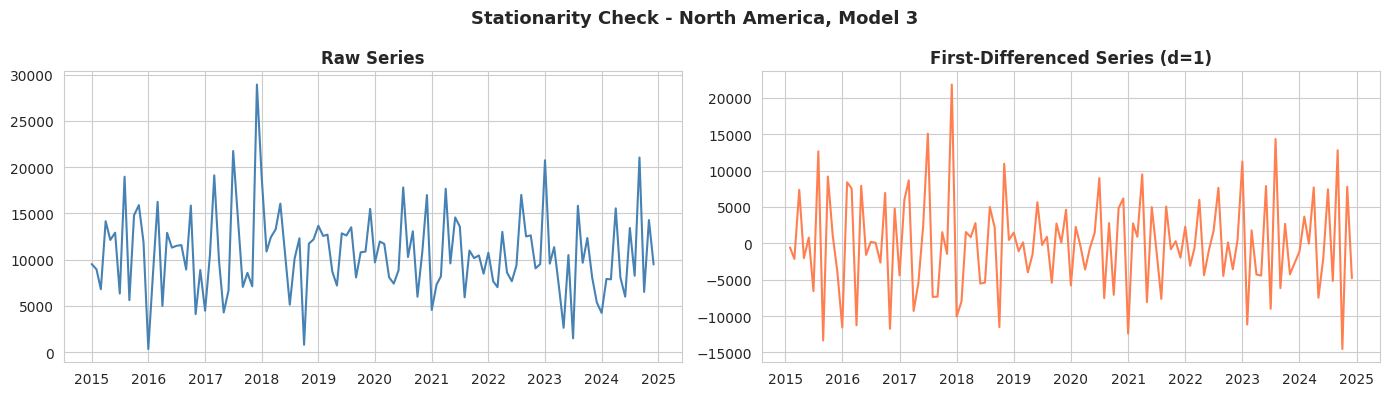


ADF on differenced series - p-value: 0.0000 -> Stationary (p < 0.05)
ARIMA order=(1,1,1) with d=1 differencing is appropriate


In [29]:
from statsmodels.tsa.stattools import adfuller

# ADF test on raw series
adf_result = adfuller(train_ts.dropna())
print('=== ADF Test - Raw Series ===')
print(f'  ADF Statistic : {adf_result[0]:.4f}')
print(f'  p-value       : {adf_result[1]:.4f}')
print(f'  Lags used     : {adf_result[2]}')
conclusion = 'Stationary (p < 0.05)' if adf_result[1] < 0.05 else 'Non-Stationary - differencing needed (d=1)'
print(f'  Conclusion    : {conclusion}')

# Plot raw vs differenced
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_ts.index, train_ts.values, color='steelblue')
axes[0].set_title('Raw Series', fontweight='bold')

diff_ts = train_ts.diff().dropna()
axes[1].plot(diff_ts.index, diff_ts.values, color='coral')
axes[1].set_title('First-Differenced Series (d=1)', fontweight='bold')

plt.suptitle('Stationarity Check - North America, Model 3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ADF on differenced series
adf_diff = adfuller(diff_ts)
conc2 = 'Stationary (p < 0.05)' if adf_diff[1] < 0.05 else 'Still non-stationary'
print(f'\nADF on differenced series - p-value: {adf_diff[1]:.4f} -> {conc2}')
print('ARIMA order=(1,1,1) with d=1 differencing is appropriate')


In [30]:
# Fit ARIMA(1,1,1) on training series
print('Fitting ARIMA(1,1,1)...')
arima_model  = ARIMA(train_ts, order=(1, 1, 1))
arima_result = arima_model.fit()
print(arima_result.summary())


Fitting ARIMA(1,1,1)...
                               SARIMAX Results                                
Dep. Variable:       Production_Units   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1173.719
Date:                Wed, 13 May 2026   AIC                           2353.439
Time:                        17:07:38   BIC                           2361.776
Sample:                    01-01-2015   HQIC                          2356.824
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0549      0.090     -0.609      0.543      -0.232       0.122
ma.L1         -1.0000      0.100     -9.977      0.000      -1.196      -0.804
sigma2      2.083e+07   4.81

In [31]:
# Forecast the test period
forecast_obj  = arima_result.get_forecast(steps=n_test)
forecast_mean = forecast_obj.predicted_mean
conf_int      = forecast_obj.conf_int()

# Evaluation metrics
ts_mae  = mean_absolute_error(test_ts, forecast_mean)
ts_rmse = np.sqrt(mean_squared_error(test_ts, forecast_mean))
ts_r2   = r2_score(test_ts, forecast_mean)

print('ARIMA Forecast Evaluation')
print(f'  MAE  : {ts_mae:.2f}')
print(f'  RMSE : {ts_rmse:.2f}')
print(f'  R2   : {ts_r2:.4f}')


ARIMA Forecast Evaluation
  MAE  : 2878.42
  RMSE : 3463.22
  R2   : -0.1174


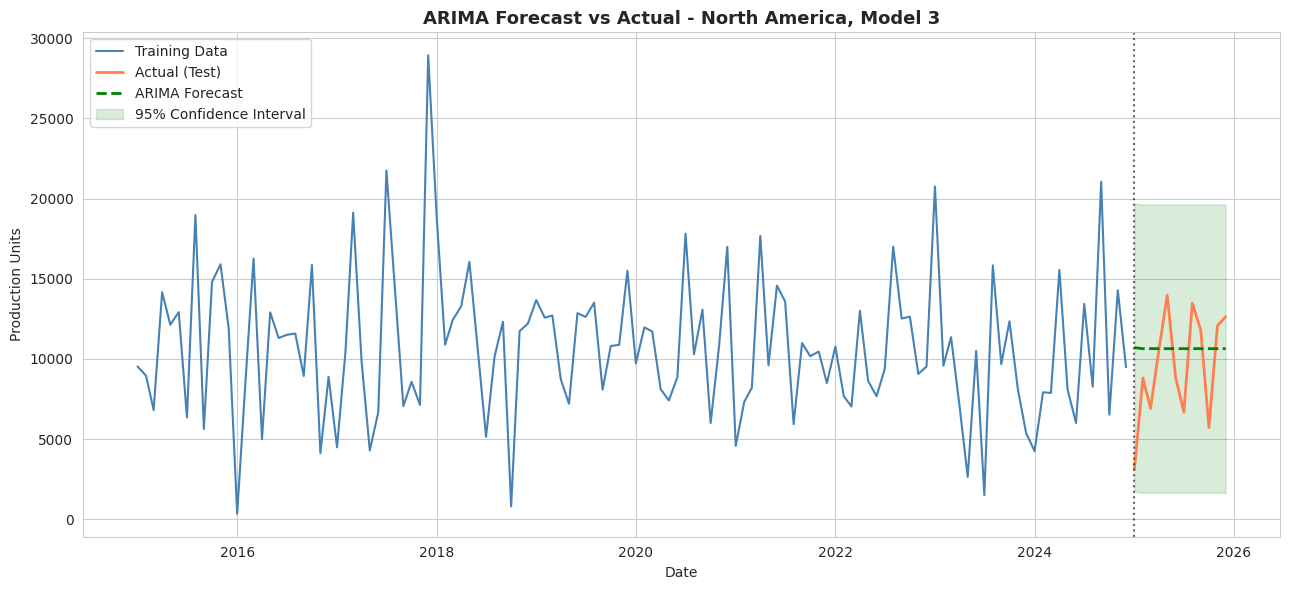

In [32]:
# Plot forecast vs actual
plt.figure(figsize=(13, 6))
plt.plot(train_ts.index, train_ts.values,           label='Training Data',        color='steelblue', linewidth=1.5)
plt.plot(test_ts.index,  test_ts.values,            label='Actual (Test)',         color='coral',     linewidth=2)
plt.plot(forecast_mean.index, forecast_mean.values, label='ARIMA Forecast',        color='green',     linewidth=2, linestyle='--')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color='green', alpha=0.15, label='95% Confidence Interval')
plt.axvline(test_ts.index[0], color='black', linestyle=':', alpha=0.6)
plt.title('ARIMA Forecast vs Actual - North America, Model 3', fontweight='bold', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Production Units')
plt.legend()
plt.tight_layout()
plt.show()


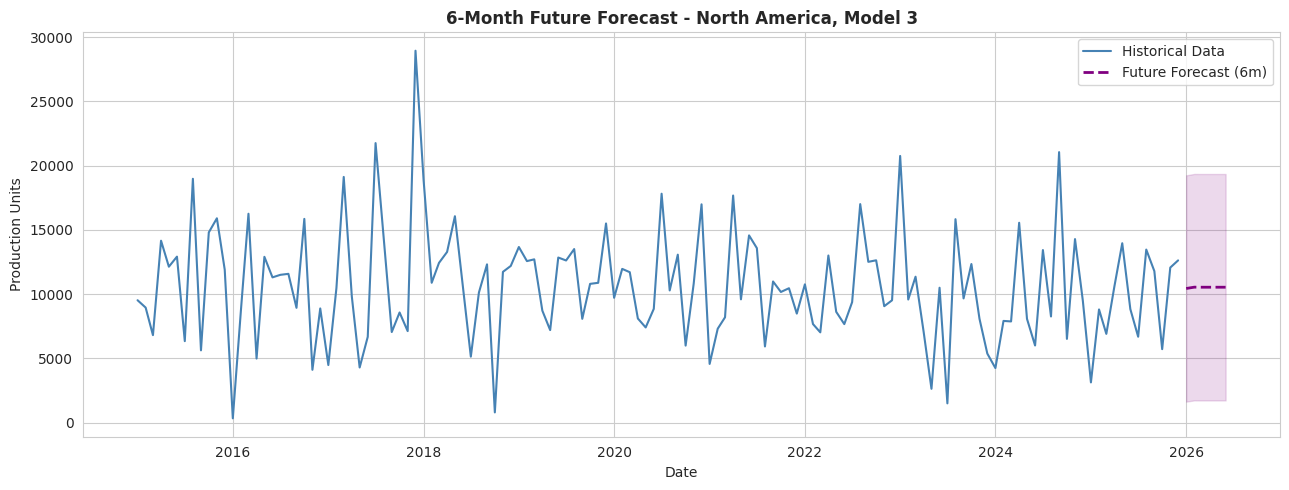

In [33]:
# 6-month future forecast beyond the dataset
future_model = ARIMA(ts, order=(1, 1, 1)).fit()
future_fc    = future_model.get_forecast(steps=6)
future_mean  = future_fc.predicted_mean
future_conf  = future_fc.conf_int()

plt.figure(figsize=(13, 5))
plt.plot(ts.index,          ts.values,          label='Historical Data',      color='steelblue', linewidth=1.5)
plt.plot(future_mean.index, future_mean.values, label='Future Forecast (6m)', color='purple',    linewidth=2, linestyle='--')
plt.fill_between(future_conf.index, future_conf.iloc[:, 0], future_conf.iloc[:, 1],
                 color='purple', alpha=0.15)
plt.title('6-Month Future Forecast - North America, Model 3', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Production Units')
plt.legend()
plt.tight_layout()
plt.show()


---
## Step 10: Conclusion

This project built a complete end-to-end ML pipeline on Tesla EV deliveries and production data (2015-2025).